# 03 · Stationary univariate analysis and information expansion

The app's Viglione project is a GEV case study for the Kamp at Zwettl, not an LP-III tutorial.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Systematic and temporal information
Compare the record ending in 2001 with the record including the 2002 flood and ending in 2005.
Temporal expansion adds three interval floods and one perception-threshold record to the 51 exact observations in the shorter input.
Each curve below comes from its own saved analysis, with its own priors and sampler configuration.

,Setting,Saved choice
0,Analysis,UnivariateAnalysis
1,InputData,Systematic (1951-2001)
2,BayesianAnalysis.Type,DEMCzs
3,BayesianAnalysis.NumberOfChains,6
4,BayesianAnalysis.ThinningInterval,30
5,BayesianAnalysis.WarmupIterations,1750
6,BayesianAnalysis.Iterations,3500
7,BayesianAnalysis.UseSimulationDefaults,True
8,BayesianAnalysis.PRNGSeed,12345
9,BayesianAnalysis.CredibleIntervalWidth,0.90000000000000002


,Parameter,Estimate,Fixed,Lower,Upper,Prior
0,Location (ξ),42.871446,False,-1.000000e+03,1000.0,Numerics.Distributions.Uniform
1,Scale (α),21.184674,False,1.110223e-16,1000.0,Numerics.Distributions.Uniform
2,Shape (κ),-0.119352,False,-1.000000e+01,10.0,Numerics.Distributions.Uniform


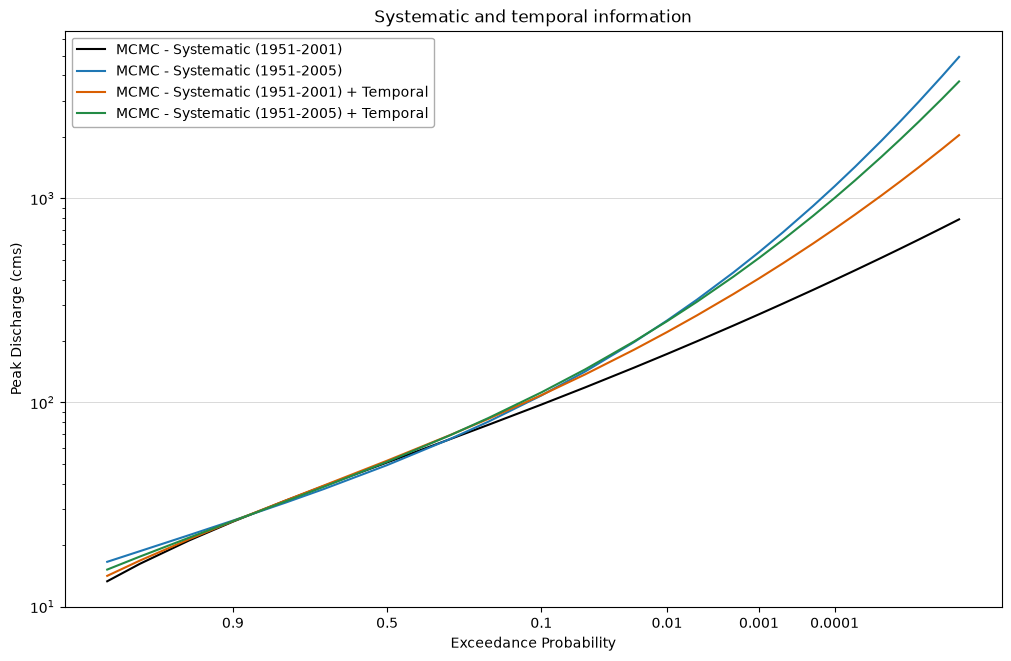

In [2]:
PROJECT = "viglione-et-al-2013"
groups = json.loads((ROOT / "curriculum-cases.json").read_text(encoding="utf-8"))
names = next(g["names"] for g in groups if g["notebook"] == "03")
cases = {name: saved_case(PROJECT, name, run=RUN_ANALYSES) for name in names}
base = cases["MCMC - Systematic (1951-2001)"]
display(base.settings)
display(base.parameters)
compare_frequency([cases[names[i]] for i in (0, 1, 2, 3)], "Systematic and temporal information")

## Causal information and combined expansion
The causal alternatives add a Normal quantile prior at AEP 0.002 with mean 480 and standard deviation 80 m³/s.
This is external information about a quantile, not an additional observed flood. Compare it with temporal expansion and their combination.
The three-prior alternative instead uses AEPs 0.1, 0.01 and 0.001 with Normal means 100, 250 and 500, and standard deviations 20, 40 and 60 m³/s.

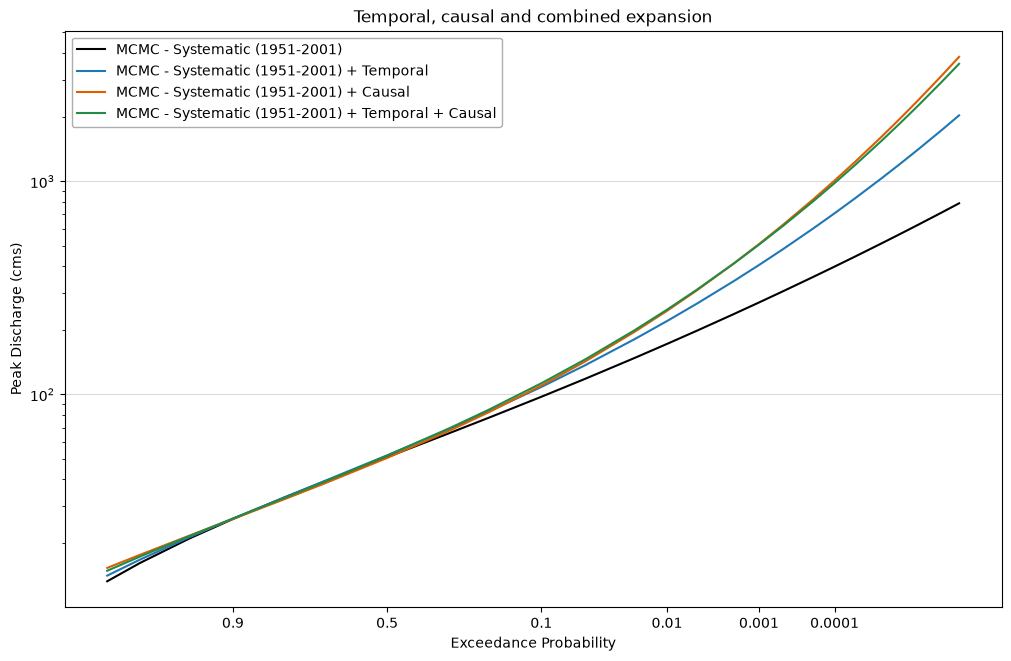

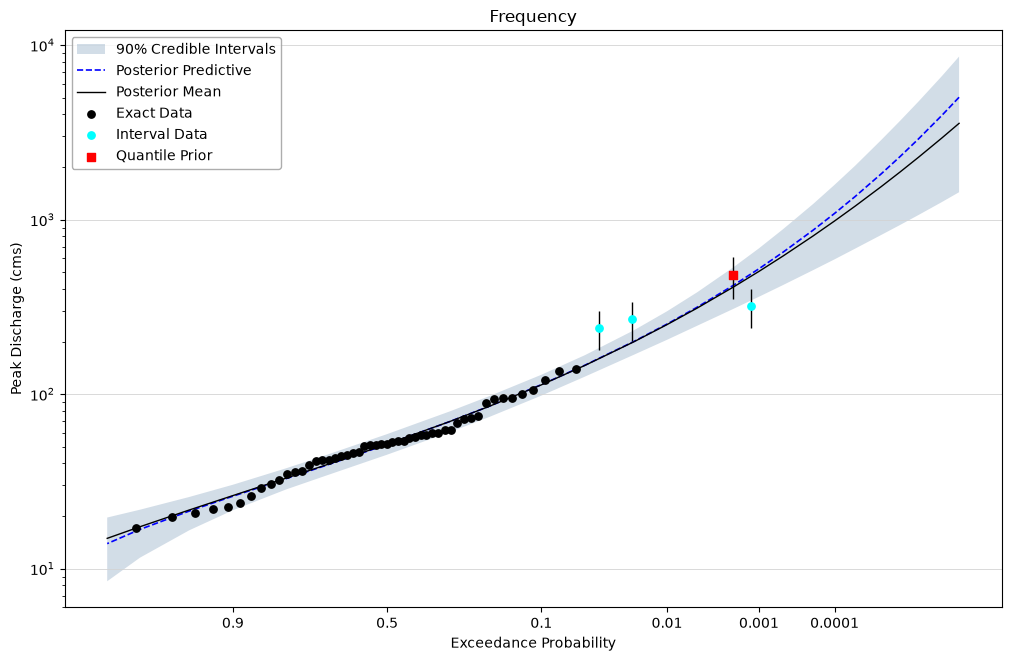

,AEP,Posterior Predictive,Posterior Mean
0,0.500,49.138030,49.244581
1,0.100,105.517421,105.264835
2,0.010,232.188942,230.438761
3,0.002,384.273853,376.619709
4,0.001,475.771545,462.119036


In [3]:
compare_frequency([cases[names[i]] for i in (0, 2, 4, 6)], "Temporal, causal and combined expansion")
combined = cases["MCMC - Systematic (1951-2001) + Temporal + Causal"]
combined.show("frequency")
display(cases[names[8]].frequency_table())

## Uncertainty and diagnostics
Read credible intervals alongside the configured point estimate and posterior predictive curve.
The separate gallery contains trace, posterior density, histogram, autocorrelation, mean log-likelihood, pair-density and influence views.
Fresh-run receipts record numerical diagnostics; successful rendering is not evidence of sampler convergence.

Fit metrics below are retained per case for provenance. They are not ranked across rows because the observation periods,
historical-information treatments, or priors differ.

Source context: [Viglione et al. (2013), *Flood frequency hydrology: 3. A Bayesian analysis*](https://doi.org/10.1029/2011WR010782).

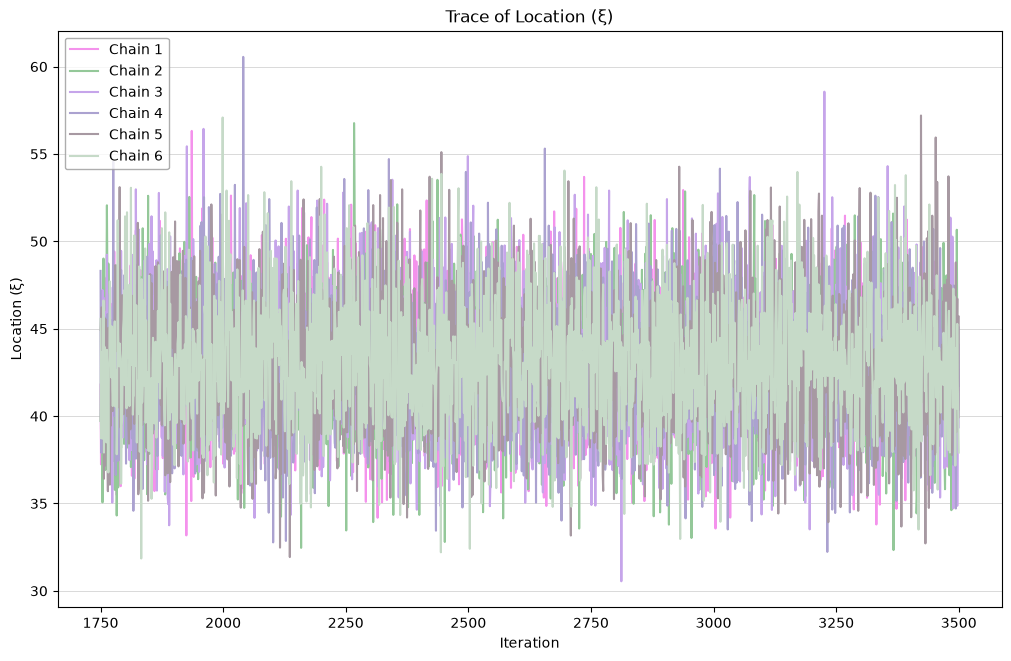

,Analysis,Input / response,Analysis type,AIC,BIC,DIC,RMSE,Metric note,Comparison scope
0,MCMC - Systematic (1951-2001),Systematic (1951-2001),UnivariateAnalysis,479.454137,485.249613,479.228404,3.670305,,Descriptive only — rows may use different resp...
1,MCMC - Systematic (1951-2005),Systematic (1951-2005),UnivariateAnalysis,531.997536,538.019536,531.974867,35.413674,,Descriptive only — rows may use different resp...
2,MCMC - Systematic (1951-2001) + Temporal,Systematic (1951-2001) + Temporal Expansion,UnivariateAnalysis,510.435497,522.424853,510.440752,20.626109,,Descriptive only — rows may use different resp...
3,MCMC - Systematic (1951-2005) + Temporal,Systematic (1951-2005) + Temporal Expansion,UnivariateAnalysis,561.682515,573.701574,561.618631,16.622534,,Descriptive only — rows may use different resp...
4,MCMC - Systematic (1951-2001) + Causal,Systematic (1951-2001),UnivariateAnalysis,481.981953,487.777430,479.641085,10.506156,,Descriptive only — rows may use different resp...
5,MCMC - Systematic (1951-2005) + Causal,Systematic (1951-2005),UnivariateAnalysis,532.053411,538.075411,530.287905,34.312716,,Descriptive only — rows may use different resp...
6,MCMC - Systematic (1951-2001) + Temporal + Causal,Systematic (1951-2001) + Temporal Expansion,UnivariateAnalysis,511.285550,523.274907,509.864828,26.565751,,Descriptive only — rows may use different resp...
7,MCMC - Systematic (1951-2005) + Temporal + Causal,Systematic (1951-2005) + Temporal Expansion,UnivariateAnalysis,561.857722,573.876782,560.423239,16.628365,,Descriptive only — rows may use different resp...
8,MCMC - Systematic (1951-2001) + 3 Quantile Priors,Systematic (1951-2001),UnivariateAnalysis,481.339594,487.135071,478.855708,8.035576,,Descriptive only — rows may use different resp...


,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,MCMC - Systematic (1951-2001),saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
1,MCMC - Systematic (1951-2005),saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
2,MCMC - Systematic (1951-2001) + Temporal,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
3,MCMC - Systematic (1951-2005) + Temporal,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
4,MCMC - Systematic (1951-2001) + Causal,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
5,MCMC - Systematic (1951-2005) + Causal,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
6,MCMC - Systematic (1951-2001) + Temporal + Causal,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
7,MCMC - Systematic (1951-2005) + Temporal + Causal,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt
8,MCMC - Systematic (1951-2001) + 3 Quantile Priors,saved-app,sha256:6f6f984f8d03,5b4883c41ba4,saved in project snapshot,saved snapshot; no rerun receipt


In [4]:
combined.show("diagnostic_trace")
display(case_metrics(list(cases.values())))
display(case_provenance(list(cases.values())))